In [1]:
import floodlight as floodlight
import pandas as pd
import numpy as np
import os
from floodlight import XY, Pitch
import floodlight.io.kinexon as knx
import floodlight.io.dfl as dfl
from floodlight.models.space import DiscreteVoronoiModel
from floodlight.models.kinetics import MetabolicPowerModel
from floodlight.models.kinematics import DistanceModel, VelocityModel, AccelerationModel
from floodlight.transforms.filter import butterworth_lowpass

from scipy.signal import find_peaks

import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

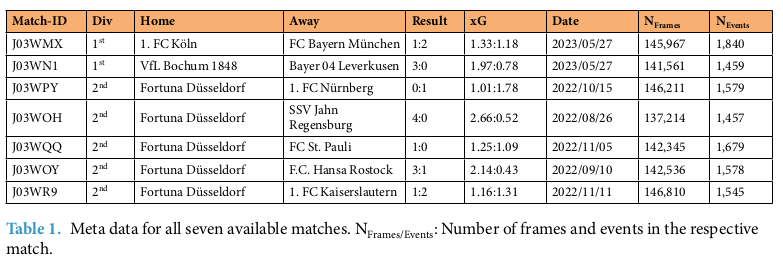

## Load Data

With the following code, you load the position data with the `floodlight` package.
You first set the `match_id`, then get the path for the matchinfo-file and the position data-file. Then, you load the position data with the `read_position_data_xml` function from floodlight's `dfl` module.

In [2]:
DATA_DIR = r'C:\Users\arnau\Sciebo\SharedDrive_Arnaud_Franziska\data\open_data2223'
ls_match_ids = ['J03WMX', 'J03WN1', 'J03WPY', 'J03WOH', 'J03WQQ', 'J03WOY', 'J03WR9']

In [3]:
match_id = 'J03WMX'

In [4]:
path_positions = os.path.join(DATA_DIR, [x for x in os.listdir(DATA_DIR) if match_id in x and 'positions' in x][0])
path_events = os.path.join(DATA_DIR, [x for x in os.listdir(DATA_DIR) if match_id in x and 'events' in x][0])
path_info = os.path.join(DATA_DIR, [x for x in os.listdir(DATA_DIR) if match_id in x and 'matchinformation' in x][0])

In [5]:
xy, possession, ballstatus, teamsheets, pitch = dfl.read_position_data_xml(path_positions, path_info, teamsheet_home=None, teamsheet_away=None)


The following cell reads the event data from the events-XML-file. You won't need the events for the subsequent analysis, this is just for practice.

In [6]:
events, teamsheets, pitch = dfl.read_event_data_xml(path_events, path_info)

c:\Users\arnau\Documents\projetde\runs-in-behind\.venv\Lib\site-packages\floodlight\core\events.py:80: UserWarning: The 'gameclock' column does not match the defined value range (from floodlight.core.definitions). This may lead to unexpected behavior of methods using this column.
  warnings.warn(


Hier wird nun die ID für das jeweilige Spiel vergeben und die Positionsdaten geladen. Ich habe schon mal die ID für das Bochum - Leverkusen Spiel eingetragen, du kannst aber auch jedes andere Spiel aus der Liste oben verwenden.

Die *floodlight*-Konvention sieht vor, dass jedes Spiel aus den Events (die sind für uns hier erstmal irrelevant), einem *xy*-Objekt, einem np-array mit dem Ballbesitz, einem np-array mit dem Ballstatus (aktiv/nicht aktiv) sowie einem *teamsheets*-Objekt und einem *pitch*-Objekt besteht. Wichtig ist hier vor allem das *xy*-Objekt, das die Positionsdaten enthält und wiederum eigentlich ein dictionary ist, das die Daten erstmal nach Halbzeiten trennt und dann für beide Mannschaften sowie den Ball getrennt ausgibt. Mit dem Format muss man ein bisschen warm werden, aber alle Downstream-Analysen in *floodlight* sind an dieses Format angepasst, deshalb empfiehlt es sich, es einfach erstmal so zu verwenden.


In [7]:
pitch.sport = "football"

xy_firsthalf_home = xy['firstHalf']['Home']
xy_firsthalf_away = xy['firstHalf']['Away']

xy_secondhalf_home = xy['secondHalf']['Home']
xy_secondhalf_away = xy['secondHalf']['Away']

possession_firsthalf = possession['firstHalf']
possession_secondhalf = possession['secondHalf']

## Get Velocity

Hier wird aus den Positionsdaten die Geschwindigkeit berechnet, die wir ja für das regelbasierte Schneiden der Positionsdaten benötigen. Auch hier hat *floodlight* die entsprechenden Funktionen bereits implementiert und wir können einfach ein sogenanntes **VelocityModel**-Objekt aufrufen, das die Geschwindigkeit für uns berechnet. Ich speichere hier die Arrays mit den Geschwindigkeiten der Spieler für beide Teams und beide Halbzeiten in einem Velocity-Dictionary.

### Get Velocities for All Halves and Teams

In [8]:
vm = VelocityModel()

velocity_dict = {}

for team in ['Home', 'Away']:
    for half in ['firstHalf', 'secondHalf']:
        vm.fit(xy[half][team])
        if half not in velocity_dict:
            velocity_dict[half] = {}
        velocity_dict[half][team] = vm.velocity().property

In [9]:
xy_filt = butterworth_lowpass(xy_firsthalf_home, remove_short_seqs=True, Wn=.5, order=1)

vm = VelocityModel()
am = AccelerationModel()

vm.fit(xy_filt)
velocity_1st_home = vm.velocity().property

am.fit(xy_filt)
acceleration_1st_home = am.acceleration().property

In [10]:
def moving_average(a, n=3):
    ret = np.nancumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

vel_rolling = moving_average(velocity_1st_home[:,9], n=20)

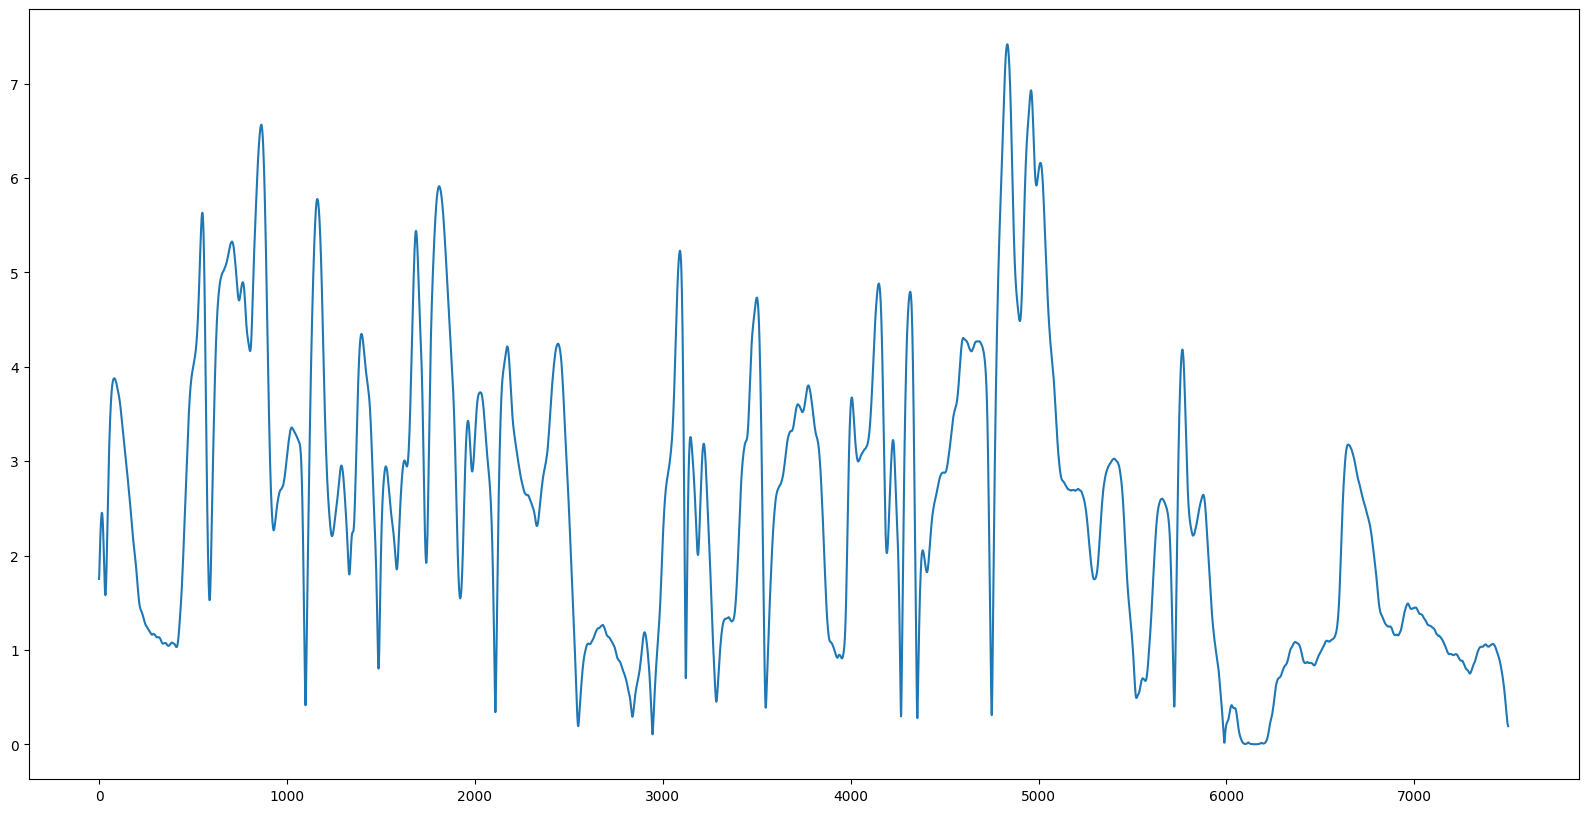

In [11]:
MINS = 5
FRAMES = MINS * 60 * 25

plt.figure(figsize=(20,10))
#plt.plot(velocity_dict['firstHalf']['Home'][:FRAMES,9])
plt.plot(velocity_1st_home[:FRAMES,9])
#plt.plot(vel_rolling[:FRAMES])
#plt.plot(acceleration_1st_home[:FRAMES,9])

## Discrete Movement Segmentation (Llana et al. 2022)

Instead of extracting only frames above a velocity threshold, this approach **segments the entire speed signal** into discrete movements using **valley detection**. Local minima (valleys) in the smoothed speed signal serve as boundaries between consecutive movements. Each valley-to-valley segment is one discrete movement; its peak speed determines the speed category (walking / jogging / running / sprinting).

Three key reference points per movement (Llana et al. 2022, Ch. 2):
1. **Valley start (origin)** — where the player begins accelerating
2. **Peak frame** — frame of maximum speed; used to assign attack/defense context
3. **Peak end (destination)** — where the player starts decelerating

See `llana2022_movement_segmentation.md` for a full summary of the approach.

In [12]:
# Timecode helpers (defined here so they are available for movement extraction;
# also redefined in the HI run section below — identical functions)
def sec_to_minute(seconds):
    minutes = seconds // 60
    seconds = seconds % 60
    return f"{int(minutes)}:{int(seconds):02d}"

def frame_to_minute(frame, frate=25):
    return sec_to_minute(frame / frate)


In [13]:
def classify_speed_category(peak_speed_kmh, thresholds):
    if peak_speed_kmh < thresholds['walking']:
        return 'walking'
    elif peak_speed_kmh < thresholds['jogging']:
        return 'jogging'
    elif peak_speed_kmh < thresholds['running']:
        return 'running'
    else:
        return 'sprinting'


In [14]:
# Speed category thresholds (km/h) — standard football science conventions
SPEED_THRESHOLDS = {'walking': 7, 'jogging': 14, 'running': 21}


# Compute Butterworth-filtered velocity for all halves and teams.
# Smoothed signal is better suited for valley detection than the raw derivative.
xy_all = {
    'firstHalf':  {'Home': xy_firsthalf_home,  'Away': xy_firsthalf_away},
    'secondHalf': {'Home': xy_secondhalf_home, 'Away': xy_secondhalf_away},
}

velocity_filtered_dict = {
    'firstHalf':  {'Home': None, 'Away': None},
    'secondHalf': {'Home': None, 'Away': None},
}

for half, teams in xy_all.items():
    for team, xy_data in teams.items():
        xy_f = butterworth_lowpass(xy_data, remove_short_seqs=True, Wn=0.5, order=1)
        vm_f = VelocityModel()
        vm_f.fit(xy_f)
        velocity_filtered_dict[half][team] = vm_f.velocity().property


In [15]:

def extract_movements_for_player(player_id, velocities, tracking_data, possession,
                                  min_valley_distance=10):
    """
    Segment a player's speed signal into discrete movements via valley detection.

    Valleys (local minima) in the smoothed speed signal define segment boundaries.
    Each valley-to-valley interval represents one discrete movement. The start of
    each segment is the valley frame itself (origin = point of acceleration onset).

    Parameters
    ----------
    min_valley_distance : int
        Minimum number of frames between two valleys (avoids noise-driven splits).
        At 25 fps, 10 frames = 0.4 seconds.
    """
    player_velocity = velocities[:, player_id]  # m/s

    # Replace NaN with 0 for valley detection (NaN = player not tracked)
    vel_for_peaks = np.where(np.isnan(player_velocity), 0.0, player_velocity)

    # Find valleys = peaks of the negated signal
    valleys, _ = find_peaks(-vel_for_peaks, distance=min_valley_distance)

    # Use signal start and end as additional boundaries
    boundaries = np.unique(np.concatenate([[0], valleys, [len(player_velocity) - 1]]))

    movements = []
    mov_idx = 0
    for i in range(len(boundaries) - 1):
        start = int(boundaries[i])
        end = int(boundaries[i + 1])  # exclusive: next valley is start of next segment

        if end - start < 3:
            continue

        frames = np.arange(start, end)
        v = player_velocity[start:end]

        if np.all(np.isnan(v)):
            continue

        x = tracking_data[start:end, ::2][:, player_id]
        y = tracking_data[start:end, 1::2][:, player_id]
        p = possession[start:end]

        movements.append(pd.DataFrame({
            'frame': frames, 'x': x, 'y': y,
            'velocity': v, 'possession': p,
            'movement_id' : mov_idx
        }))
        mov_idx += 1

    return movements


def extract_discrete_movements_all_players(velocities, tracking_data, possession,
                                            min_valley_distance=10):
    """Extract discrete movements for all players in a tracking data array."""
    n_players = velocities.shape[1]
    return {
        player_id: extract_movements_for_player(
            player_id, velocities, tracking_data, possession, min_valley_distance)
        for player_id in range(n_players)
    }


def summarize_movements_to_dataframe(movements_dict, teamsheet, framerate=25):
    """
    Convert discrete movement data to a summary DataFrame (one row per movement).

    Columns mirror the HI run summary with additions:
    - peak_frame     : frame of maximum speed within the segment
    - x_peak, y_peak : position at peak speed (destination per Llana et al.)
    - peak_speed_kmh : maximum speed reached in this movement
    - speed_category : walking / jogging / running / sprinting
    """
    rows = []
    for xID, movements in movements_dict.items():
        player_info = teamsheet.loc[teamsheet['xID'] == xID]
        if player_info.empty:
            continue

        player_name = player_info['player'].values[0]
        position    = player_info['position'].values[0]
        team_name   = player_info['team'].values[0]
        jersey_id   = player_info['jID'].values[0]

        for df in movements:
            if df.empty or df['velocity'].isna().all():
                continue

            v_ms = df['velocity'].values
            valid_v = np.where(np.isnan(v_ms), -np.inf, v_ms)
            peak_idx = int(np.argmax(valid_v))
            peak_speed_kmh = float(v_ms[peak_idx]) * 3.6 if not np.isnan(v_ms[peak_idx]) else 0.0

            deltas = df[['x', 'y']].diff().dropna()
            distance_m = np.sqrt((deltas ** 2).sum(axis=1)).sum()

            rows.append({
                'start_frame':      df['frame'].iloc[0],
                'end_frame':        df['frame'].iloc[-1],
                'peak_frame':       df['frame'].iloc[peak_idx],
                'xID':              xID,
                'player':           player_name,
                'position':         position,
                'team':             team_name,
                'possession':       "Home" if df['possession'].iloc[0] == 1 else "Away",
                'jID':              jersey_id,
                'x_start':          df['x'].iloc[0],
                'y_start':          df['y'].iloc[0],
                'x_end'  :          df['x'].iloc[-1],
                'y_end':            df['y'].iloc[-1],
                'x_peak':           df['x'].iloc[peak_idx],
                'y_peak':           df['y'].iloc[peak_idx],
                'peak_speed_kmh':   peak_speed_kmh,
                'speed_category':   classify_speed_category(peak_speed_kmh, SPEED_THRESHOLDS),
                'avg_velocity_kmh': np.nanmean(v_ms) * 3.6,
                'distance_m':       distance_m,
                'duration_s':       len(df) / framerate,
            })

    return pd.DataFrame(rows)


In [16]:
# Extract discrete movements for all halves and teams
ls_movement_dfs = []

dict_trajectories = {}
for team in ['Home', 'Away']:
    ls_movements_team = []
    for half in ['firstHalf', 'secondHalf']:
        # read_event_data_xml does not call add_xIDs(), so the xID column is missing
        # from the teamsheets it returns. Add it here before passing to summarize().
        teamsheets[team].add_xIDs()

        xy_f = butterworth_lowpass(xy[half][team], remove_short_seqs=True, Wn=0.5, order=1).xy

        movements_dict = extract_discrete_movements_all_players(
            velocity_filtered_dict[half][team],
            xy_f,
            possession[half],
            min_valley_distance=10
        )
        summary_df = summarize_movements_to_dataframe(
            movements_dict, teamsheets[team].teamsheet, framerate=25)

        summary_df['half'] = half
        summary_df['location'] = team
        summary_df['start_timecode'] = summary_df.apply(
            lambda x: frame_to_minute(x['start_frame']) if x.half == 'firstHalf'
            else frame_to_minute(x['start_frame'] + 67500), axis=1)
        summary_df['end_timecode'] = summary_df.apply(
            lambda x: frame_to_minute(x['end_frame']) if x.half == 'firstHalf'
            else frame_to_minute(x['end_frame'] + 67500), axis=1)

        ls_movement_dfs.append(summary_df)
        ls_movements_team.append(movements_dict)
    merged = {
        k: ls_movements_team[0][k] + ls_movements_team[1][k]
        for k in ls_movements_team[0]
    }

    dict_trajectories[team] = merged
        
df_movements = pd.concat(ls_movement_dfs, ignore_index=True)
df_movements = df_movements[df_movements.distance_m > 0] # debatable

print(f"Total discrete movements extracted: {len(df_movements)}")
df_movements['speed_category'].value_counts()


Total discrete movements extracted: 46115


speed_category
walking      33263
jogging       8520
running       3543
sprinting      789
Name: count, dtype: int64

## Investigate Playing Direction for Both Halves

Clearly, the home team plays right to left first half and left to right second half.
A double check with the video indicated that the Scouting Feed footage has the home team in the same direction.

<Axes: >

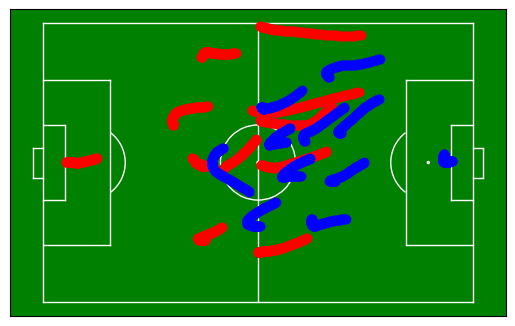

In [17]:
fig, ax = plt.subplots()
pitch.plot(ax=ax)

f_start = 0
f_end = 100

xy['firstHalf']['Away'].plot([np.arange(f_start,f_end)], ax=ax, color='red')
xy['firstHalf']['Home'].plot([np.arange(f_start, f_end)], ax=ax, color='blue')

<Axes: >

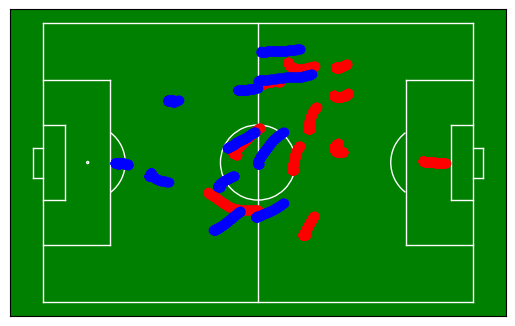

In [18]:
fig, ax = plt.subplots()
pitch.plot(ax=ax)

f_start = 0
f_end = 100

xy['secondHalf']['Away'].plot([np.arange(f_start,f_end)], ax=ax, color='red')
xy['secondHalf']['Home'].plot([np.arange(f_start, f_end)], ax=ax, color='blue')

## Store Raw Trajectories to CSV


In [ ]:
if not os.path.exists("data/movement_trajectories/" + match_id):
    os.makedirs("data/movement_trajectories/" + match_id)

for team in tqdm(['Home', 'Away'], total=2):
    for ix, ls_dfs_player in tqdm(dict_trajectories[team].items(), total=len(dict_trajectories[team]), desc=f"Processing {team}"):
        player_info = teamsheets[team].teamsheet.loc[teamsheets[team].teamsheet['xID'] == ix]
        if player_info.empty:
            continue
        try:
            df_player = pd.concat(ls_dfs_player).reset_index(names='run_frame')
            df_player['player'] = player_info['player'].values[0]
            df_player['jersey'] = player_info['jID'].values[0]
            df_player['position'] = player_info['position'].values[0]
            df_player['team'] = player_info['team'].values[0]

            df_player.to_csv(f"data/movement_trajectories/{match_id}/{team}_{player_info['player'].values[0]}_{player_info['xID'].values[0]}.csv", index=False)
        except ValueError:
            print(f"Skipping player {player_info['player'].values[0]} (xID {ix}) due to empty movement data.")


## Get Running Distances for All Players

In [21]:
ls_dfs_distance = []
for half, teams in xy_all.items():
    for team, xy_data in teams.items():
        xy_f = butterworth_lowpass(xy_data, remove_short_seqs=True, Wn=0.5, order=1)
        dm = DistanceModel()
        dm.fit(xy_f)
        df_players = teamsheets[team].teamsheet
        df_players['distance_covered'] = np.nansum(dm.distance_covered().property, axis=0)
        df_players['location'] = team
        df_players['half'] = half
        ls_dfs_distance.append(df_players)

In [22]:
df_distances = pd.concat(ls_dfs_distance).groupby(['location', 'team', 'player']).agg(
    total_distance_m=pd.NamedAgg(column='distance_covered', aggfunc='sum'),
    position=pd.NamedAgg(column='position', aggfunc='first'),
    jID=pd.NamedAgg(column='jID', aggfunc='first'),
)

## Compare Running Distances from Discrete Movements

In [23]:
pd.concat([
    pd.DataFrame(df_movements.groupby(['location', 'team', 'player']).distance_m.sum().sort_values(ascending=False)).round(2),
    df_distances
], axis=1).round()

distance_m  total_distance_m  \
location team              player                                            
Home     1. FC Köln        E. Martel             12208.0           11447.0   
Away     FC Bayern München Joshua Kimmich        12203.0           12050.0   
Home     1. FC Köln        Ellyes Skhiri         11881.0           11504.0   
Away     FC Bayern München Serge Gnabry          11259.0           11163.0   
                           Dayot Upamecano       10258.0            9958.0   
Home     1. FC Köln        D. Ljubicic           10210.0            8353.0   
Away     FC Bayern München M. de Ligt            10017.0            9675.0   
                           Benjamin Pavard        9889.0            9561.0   
Home     1. FC Köln        Timo Hübers            9809.0            9431.0   
                           Jonas Hector           9757.0            9957.0   
                           Jeff Chabot            9573.0            9253.0   
Away     FC Bayern München Leroy Sané             9358.0            9295.0   
                           N. Mazraoui            9292.0            8176.0   
Home     1. FC Köln        L. Maina               9248.0            7479.0   
Away     FC Bayern München Ryan Gravenberch       8524.0            5402.0   
                           Kingsley Coman         8245.0            5797.0   
Home     1. FC Köln        F. Kainz               7842.0            4107.0   
Away     FC Bayern München T. Müller              7782.0            4239.0   
Home     1. FC Köln        B. Schmitz             7147.0            3754.0   
                           D. Selke               6928.0            3646.0   
                           M. Schwäbe             5246.0            5167.0   
Away     FC Bayern München Y. Sommer              4883.0            4604.0   
Home     1. FC Köln        D. Huseinbašić         3848.0            7750.0   
                           Jan Thielmann          3558.0            7174.0   
                           K. Schindler           3165.0            6381.0   
Away     FC Bayern München Joao Cancelo           3161.0            6376.0   
                           E. Choupo-Moting       2351.0            4746.0   
Home     1. FC Köln        T. Lemperle            1624.0            3271.0   
Away     FC Bayern München Leon Goretzka          1507.0            3038.0   
Home     1. FC Köln        Kristian Pedersen      1471.0            2964.0   
Away     FC Bayern München J. Musiala             1309.0            2642.0   
                           Mathys Tel             1160.0            2340.0   
                           D. Blind                  NaN               0.0   
                           J. Stanišić               NaN               0.0   
                           S. Mané                   NaN               0.0   
                           S. Ulreich                NaN               0.0   
Home     1. FC Köln        D. Limnios                NaN               0.0   
                           Luca Kilian               NaN               0.0   
                           Mathias Olesen            NaN               0.0   
                           Timo Horn                 NaN               0.0   

                                             position  jID  
location team              player                           
Home     1. FC Köln        E. Martel              DMR    6  
Away     FC Bayern München Joshua Kimmich         DMR    6  
Home     1. FC Köln        Ellyes Skhiri          DML   28  
Away     FC Bayern München Serge Gnabry           STZ    7  
                           Dayot Upamecano        IVR    2  
Home     1. FC Köln        D. Ljubicic            ORM    7  
Away     FC Bayern München M. de Ligt             IVL    4  
                           Benjamin Pavard         RV    5  
Home     1. FC Köln        Timo Hübers            IVR    4  
                           Jonas Hector            LV   14  
                           Jeff Chabo

In [24]:
pd.DataFrame(df_movements[['player', 'speed_category']].value_counts()).unstack()

count                          
speed_category    jogging running sprinting walking
player                                             
B. Schmitz          365.0   113.0      13.0   727.0
Benjamin Pavard     387.0   148.0      23.0  1542.0
D. Huseinbašić      121.0    69.0      20.0   466.0
D. Ljubicic         292.0   150.0      68.0  1166.0
D. Selke            257.0    72.0      33.0   962.0
Dayot Upamecano     486.0   134.0      39.0  1371.0
E. Choupo-Moting     80.0    40.0       6.0   479.0
E. Martel           466.0   254.0      38.0  1155.0
Ellyes Skhiri       468.0   222.0      27.0  1329.0
F. Kainz            279.0   155.0      18.0   793.0
J. Musiala           46.0    26.0       7.0   173.0
Jan Thielmann       120.0    55.0      19.0   560.0
Jeff Chabot         387.0   110.0      28.0  1462.0
Joao Cancelo         91.0    43.0      11.0   617.0
Jonas Hector        384.0   163.0      39.0  1522.0
Joshua Kimmich      458.0   305.0      24.0  1184.0
K. Schindler        116.0    35.0      13.0   613.0
Kingsley Coman      329.0   109.0      42.0   939.0
Kristian Pedersen    69.0    18.0      10.0   200.0
L. Maina            307.0   156.0      44.0  1322.0
Leon Goretzka        45.0    32.0       5.0   230.0
Leroy Sané          242.0   133.0      57.0  1964.0
M. Schwäbe          179.0    18.0       1.0  2655.0
M. de Ligt          487.0   153.0      21.0  1328.0
Mathys Tel           44.0    21.0       5.0   166.0
N. Mazraoui         379.0   129.0      29.0  1224.0
Ryan Gravenberch    327.0   183.0      27.0   953.0
Serge Gnabry        354.0   192.0      52.0  1416.0
T. Lemperle          54.0    32.0      11.0   194.0
T. Müller           287.0   130.0      35.0   848.0
Timo Hübers         470.0   127.0      24.0  1461.0
Y. Sommer           144.0    16.0       NaN  2242.0

## Calculate Features of Runs

In [25]:
import json

path = r"C:\Users\arnau\Sciebo\SharedDrive_Arnaud_Franziska\data\direction_idsse_video.json"

with open(path, "r") as f:
    dict_direction = json.load(f)

print(dict_direction)

{'J03WMX': {'Home': {'firstHalf': 'right_to_left', 'secondHalf': 'left_to_right'}}, 'J03WN1': {'Home': {'firstHalf': 'right_to_left', 'secondHalf': 'left_to_right'}}, 'J03WPY': {'Home': {'firstHalf': 'right_to_left', 'secondHalf': 'left_to_right'}}, 'J03WOH': {'Home': {'firstHalf': 'right_to_left', 'secondHalf': 'left_to_right'}}, 'J03WQQ': {'Home': {'firstHalf': 'right_to_left', 'secondHalf': 'left_to_right'}}, 'J03WOY': {'Home': {'firstHalf': 'right_to_left', 'secondHalf': 'left_to_right'}}, 'J03WR9': {'Home': {'firstHalf': 'left_to_right', 'secondHalf': 'right_to_left'}}}


In [26]:
# direction: x-component of the L1-normalized displacement vector.
# Maps to [-1, 1] with intuitive landmarks:
#   1    = purely horizontal right
#  -1    = purely horizontal left
#   0    = purely vertical (up or down)
#   0.5  = 45° forward-diagonal
#  -0.5  = 45° backward-diagonal

dx = df_movements["x_end"] - df_movements["x_start"]
dy = df_movements["y_end"] - df_movements["y_start"]
base_direction = dx.div(dx.abs().add(dy.abs())).fillna(0)

home_by_half = dict_direction.get(match_id, {}).get("Home", {})
home_direction = df_movements["half"].map(home_by_half)

# Away team attacks in the opposite direction of Home.
player_direction = home_direction.where(
    df_movements["location"].ne("Away"),
    home_direction.map({"left_to_right": "right_to_left", "right_to_left": "left_to_right"})
)

multiplier = player_direction.map({"left_to_right": 1, "right_to_left": -1}).fillna(1)
df_movements["direction"] = base_direction * multiplier

df_movements["direction"].describe()

count    46115.000000
mean         0.005746
std          0.594261
min         -0.999998
25%         -0.540579
50%          0.016251
75%          0.545537
max          1.000000
Name: direction, dtype: float64

## Filter Movements Based on Deep Run Criteria

In [27]:
df_movements[
    (df_movements.possession == df_movements.location) &
    (df_movements.speed_category.isin(['jogging', 'running', 'sprinting'])) &
    (df_movements.duration_s > 2) &
    (df_movements.x_start > -30) &
    (df_movements.direction > 0.5)  # strong forward component
    #(df_movements.x_end > df_movements.x_start)  # ensure movement is towards opponent goal
    ]

,start_frame,end_frame,peak_frame,xID,player,position,team,possession,jID,x_start,...,peak_speed_kmh,speed_category,avg_velocity_kmh,distance_m,duration_s,half,location,start_timecode,end_timecode,direction
4,388,534,498,0,F. Kainz,ZO,1. FC Köln,Home,11,20.262496,...,13.983819,jogging,9.743837,15.844162,5.88,firstHalf,Home,0:15,0:21,0.773044
10,1113,1185,1151,0,F. Kainz,ZO,1. FC Köln,Home,11,5.135399,...,9.650700,jogging,9.047379,7.245584,2.92,firstHalf,Home,0:44,0:47,0.627228
11,1186,1281,1227,0,F. Kainz,ZO,1. FC Köln,Home,11,-0.941650,...,10.076397,jogging,9.639375,10.180099,3.84,firstHalf,Home,0:47,0:51,0.727997
25,2334,2524,2450,0,F. Kainz,ZO,1. FC Köln,Home,11,-14.929441,...,17.869479,running,12.548662,26.576687,7.64,firstHalf,Home,1:33,1:40,0.733162
37,3281,3421,3350,0,F. Kainz,ZO,1. FC Köln,Home,11,-28.746240,...,7.791562,jogging,4.389547,6.865374,5.64,firstHalf,Home,2:11,2:16,0.519687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46035,69673,69751,69731,19,Mathys Tel,STL,FC Bayern München,Away,39,-8.610304,...,18.987464,running,15.695684,13.620615,3.16,secondHalf,Away,91:26,91:30,0.856767
46036,69752,69851,69798,19,Mathys Tel,STL,FC Bayern München,Away,39,-22.054321,...,21.877041,sprinting,16.416119,18.136698,4.00,secondHalf,Away,91:30,91:34,0.849097
46077,72378,72543,72532,19,Mathys Tel,STL,FC Bayern München,Away,39,-0.074245,...,13.173911,jogging,9.502242,17.421129,6.64,secondHalf,Away,93:15,93:21,0.526629
46081,72598,72712,72602,19,Mathys Tel,STL,FC Bayern München,Away,39,-19.156722,...,13.149736,jogging,10.730167,13.602038,4.60,secondHalf,Away,93:23,93:28,0.541315


In [28]:
df_movements.groupby('speed_category').distance_m.describe().round(2)

,count,mean,std,min,25%,50%,75%,max
speed_category,,,,,,,,
jogging,8520.0,9.46,5.42,0.79,5.38,8.35,12.40,47.88
running,3543.0,18.16,8.28,1.41,12.21,16.79,22.94,51.96
sprinting,789.0,31.56,12.02,2.47,23.08,29.85,38.51,77.89
walking,33263.0,1.65,1.59,0.00,0.41,1.27,2.36,12.52


In [29]:
df_movements.distance_m.describe().round(2)


count    46115.00
mean         4.87
std          7.22
min          0.00
25%          0.75
50%          1.98
75%          5.51
max         77.89
Name: distance_m, dtype: float64

In [30]:
df_movements.distance_m.round().value_counts().sort_index()

distance_m
0.0      9136
1.0     10036
2.0      6795
3.0      4065
4.0      2642
        ...  
65.0        4
66.0        1
67.0        1
75.0        1
78.0        1
Name: count, Length: 70, dtype: int64

<Axes: >

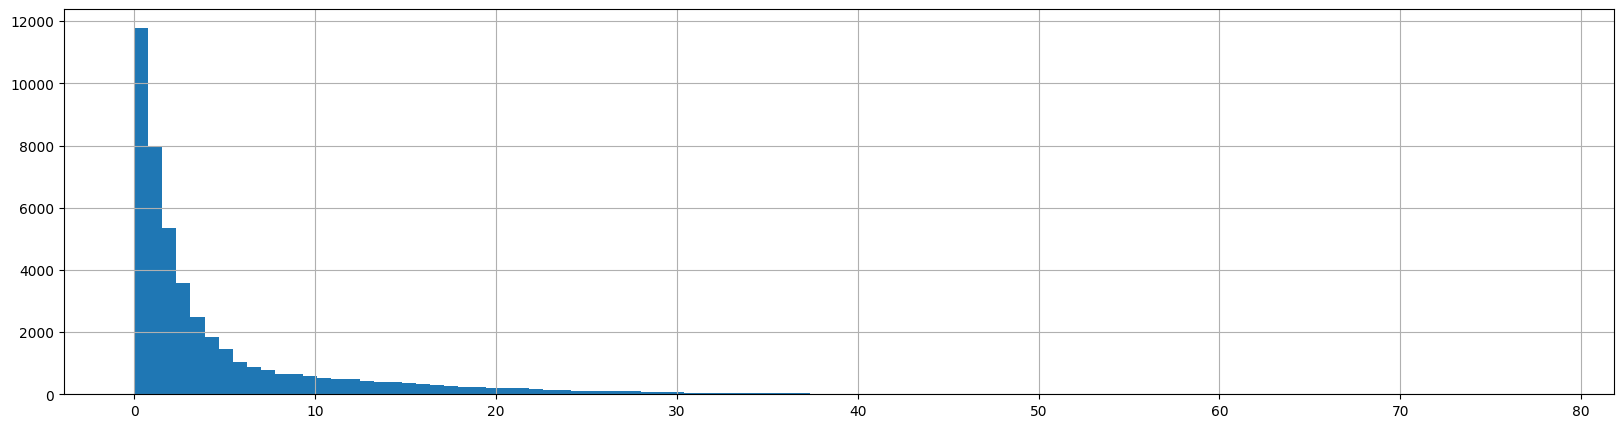

In [31]:
plt.figure(figsize=(20,5))
df_movements.distance_m.hist(bins=100)

In [ ]:
df_movements.to_csv('data/discrete_movements/'+str(match_id)+'.csv', index=False)